### Trees

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import regex as re

Pre-processing and splitting without leakage

In [2]:
# Train-only preprocessing implementation (leakage-safe)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Reload a fresh copy so preprocessing is reproducible and independent of EDA mutations
raw_data = pd.read_csv('training_data_202601.csv')
raw_data = raw_data.rename(columns={
    'Painting': 'painting',
    'On a scale of 1–10, how intense is the emotion conveyed by the artwork?': 'emotion_rating',
    'Describe how this painting makes you feel.': 'feel_describe',
    'This art piece makes me feel sombre.': 'sombre',
    'This art piece makes me feel content.': 'content',
    'This art piece makes me feel calm.': 'calm',
    'This art piece makes me feel uneasy.': 'uneasy',
    'How many prominent colours do you notice in this painting?': 'colors',
    'How many objects caught your eye in the painting?': 'objects',
    'How much (in Canadian dollars) would you be willing to pay for this painting?': 'price',
    'If you could purchase this painting, which room would you put that painting in?': 'room',
    'If you could view this art in person, who would you want to view it with?': 'exhibition_with',
    'What season does this art piece remind you of?': 'season',
    'If this painting was a food, what would be?': 'food',
    'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.': 'soundtrack'
})

likert_cols = ['sombre', 'content', 'calm', 'uneasy']


def extract_likert_value(value):
    if pd.isna(value):
        return np.nan
    match = re.match(r'^(\d+)', str(value).strip())
    return float(match.group(1)) if match else np.nan


def parse_price_value(value):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip().replace(',', '')

    range_match = re.search(r'(\d+\.?\d*)\s*(?:-|–|to)\s*(\d+\.?\d*)', text)
    if range_match:
        low, high = float(range_match.group(1)), float(range_match.group(2))
        return (low + high) / 2

    for pattern, multiplier in [
        (r'(\d+\.?\d*)\s*(?:billion|bn|b)\b', 1_000_000_000),
        (r'(\d+\.?\d*)\s*(?:million|m)\b', 1_000_000),
        (r'(\d+\.?\d*)\s*k\b', 1_000),
    ]:
        mult_match = re.search(pattern, text)
        if mult_match:
            return float(mult_match.group(1)) * multiplier

    first_num = re.search(r'(\d+\.?\d*)', text)
    if first_num:
        return float(first_num.group(1))

    return np.nan


for col in likert_cols:
    raw_data[col] = raw_data[col].apply(extract_likert_value)

raw_data['price_clean'] = raw_data['price'].apply(parse_price_value)

if 'train_ids' not in globals() or 'test_ids' not in globals():
    rng = np.random.default_rng(42)
    unique_ids = raw_data['unique_id'].dropna().unique()
    unique_ids = np.array(unique_ids)
    rng.shuffle(unique_ids)
    split_idx = int(len(unique_ids) * 0.8)
    train_ids = set(unique_ids[:split_idx])
    test_ids = set(unique_ids[split_idx:])

train_df = raw_data[raw_data['unique_id'].isin(train_ids)].copy()
test_df = raw_data[raw_data['unique_id'].isin(test_ids)].copy()

y_train = train_df['painting'].copy()
y_test = test_df['painting'].copy()

# 1) Numeric preprocessing: median imputation -> outlier cap -> log(price) -> scaling
numeric_cols = ['emotion_rating', 'sombre', 'content', 'calm', 'uneasy', 'colors', 'objects', 'price_clean']
imputer = SimpleImputer(strategy='median')

train_num = pd.DataFrame(
    imputer.fit_transform(train_df[numeric_cols]),
    columns=numeric_cols,
    index=train_df.index
)
test_num = pd.DataFrame(
    imputer.transform(test_df[numeric_cols]),
    columns=numeric_cols,
    index=test_df.index
)

price_cap = np.nanquantile(train_num['price_clean'], 0.99)
train_num['price_clean'] = np.clip(train_num['price_clean'], 0, price_cap)
test_num['price_clean'] = np.clip(test_num['price_clean'], 0, price_cap)

train_num['price_clean'] = np.log1p(train_num['price_clean'])
test_num['price_clean'] = np.log1p(test_num['price_clean'])

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_num)
X_test_num = scaler.transform(test_num)

# 2) Multi-label categorical preprocessing: comma split -> multi-hot encoding
multilabel_cols = ['room', 'exhibition_with', 'season']


def split_labels(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(',') if item.strip()]


mlb_models = {}
X_train_multi_parts = []
X_test_multi_parts = []
for col in multilabel_cols:
    mlb = MultiLabelBinarizer()
    train_labels = train_df[col].apply(split_labels)
    test_labels = test_df[col].apply(split_labels)

    train_multi = mlb.fit_transform(train_labels)
    test_multi = mlb.transform(test_labels)

    mlb_models[col] = mlb
    X_train_multi_parts.append(csr_matrix(train_multi))
    X_test_multi_parts.append(csr_matrix(test_multi))

# 3) Text preprocessing: combine text columns -> TF-IDF
text_cols = ['feel_describe', 'food', 'soundtrack']
train_text = train_df[text_cols].fillna('').agg(' '.join, axis=1)
test_text = test_df[text_cols].fillna('').agg(' '.join, axis=1)

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=2000
)
X_train_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

# Final design matrix
X_train = hstack([csr_matrix(X_train_num), *X_train_multi_parts, X_train_text], format='csr')
X_test = hstack([csr_matrix(X_test_num), *X_test_multi_parts, X_test_text], format='csr')

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Target classes:', sorted(y_train.unique()))
print('TF-IDF vocabulary size:', len(tfidf.vocabulary_))
print('Price cap (train 99th percentile):', round(float(price_cap), 2))

Train shape: (1347, 2022)
Test shape: (339, 2022)
Target classes: ['The Persistence of Memory', 'The Starry Night', 'The Water Lily Pond']
TF-IDF vocabulary size: 2000
Price cap (train 99th percentile): 227000000.0


In [3]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import json

train_groups = train_df['unique_id'].values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

gkf = GroupKFold(n_splits=5)

#### 1. Baseline: Logistic Regression

Grid search with accuracy

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

logreg_param_grid = {
    'C': [100, 10, 1, 0.1, 0.01]
}

logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ),
    param_grid=logreg_param_grid,
    cv=gkf,
    scoring='accuracy',
    n_jobs=2,
    verbose=1
)

logreg_grid_search.fit(X_train, y_train_encoded, groups=train_groups)

print(f"Best LR Params: {logreg_grid_search.best_params_}")
print(f"Best LR CV Score: {logreg_grid_search.best_score_:.4f}")

best_lr = logreg_grid_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best LR Params: {'C': 10}
Best LR CV Score: 0.8723


We can also use f1_macro for the grid search. And it gives the same C but a slightly lower CV Score.

In [6]:
logreg_param_grid = {
    'C': [100, 10, 1, 0.1, 0.01]
}

logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ),
    param_grid=logreg_param_grid,
    cv=gkf,
    scoring='f1_macro',
    n_jobs=2,
    verbose=1
)

logreg_grid_search.fit(X_train, y_train_encoded, groups=train_groups)

print(f"Best LR Params: {logreg_grid_search.best_params_}")
print(f"Best LR CV Score: {logreg_grid_search.best_score_:.4f}")

best_lr = logreg_grid_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best LR Params: {'C': 10}
Best LR CV Score: 0.8716


Important Metrics

In [9]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(
    best_lr,
    X_train,
    y_train_encoded,
    cv=gkf,
    groups=train_groups
)

In [10]:
acc_cv = accuracy_score(y_train_encoded, y_pred_cv)
print(f"CV Accuracy: {acc_cv:.4f}")

print("CV Classification Report:")
print(classification_report(y_train_encoded, y_pred_cv))

macro_f1_cv = f1_score(y_train_encoded, y_pred_cv, average='macro')
print(f"CV Macro F1: {macro_f1_cv:.4f}")

CV Accuracy: 0.8723
CV Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       449
           1       0.86      0.79      0.83       449
           2       0.84      0.93      0.88       449

    accuracy                           0.87      1347
   macro avg       0.87      0.87      0.87      1347
weighted avg       0.87      0.87      0.87      1347

CV Macro F1: 0.8716


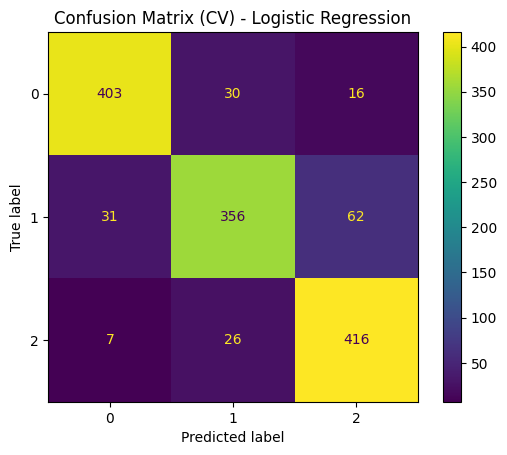

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train_encoded, y_pred_cv)
plt.title("Confusion Matrix (CV) - Logistic Regression")
plt.show()

Our baseline model shows that class 1 is harder to predict given an obviously lower recall. 

#### 2. Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, 50, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=gkf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train_encoded, groups=train_groups)

print(f"Best RF Params: {rf_grid_search.best_params_}")
print(f"Best RF CV Score: {rf_grid_search.best_score_:.4f}")

best_rf = rf_grid_search.best_estimator_

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Best RF Params: {'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV Score: 0.8850


In [15]:
y_pred_rf_cv = cross_val_predict(
    best_rf,
    X_train,
    y_train_encoded,
    cv=gkf,
    groups=train_groups
)

acc_rf_cv = accuracy_score(y_train_encoded, y_pred_rf_cv)
print(f"RF CV Accuracy: {acc_rf_cv:.4f}")

print("RF CV Classification Report:")
print(classification_report(y_train_encoded, y_pred_rf_cv))

macro_f1_rf = f1_score(y_train_encoded, y_pred_rf_cv, average='macro')
print(f"RF CV Macro F1: {macro_f1_rf:.4f}")

RF CV Accuracy: 0.8857
RF CV Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       449
           1       0.86      0.81      0.83       449
           2       0.90      0.91      0.90       449

    accuracy                           0.89      1347
   macro avg       0.88      0.89      0.88      1347
weighted avg       0.88      0.89      0.88      1347

RF CV Macro F1: 0.8849


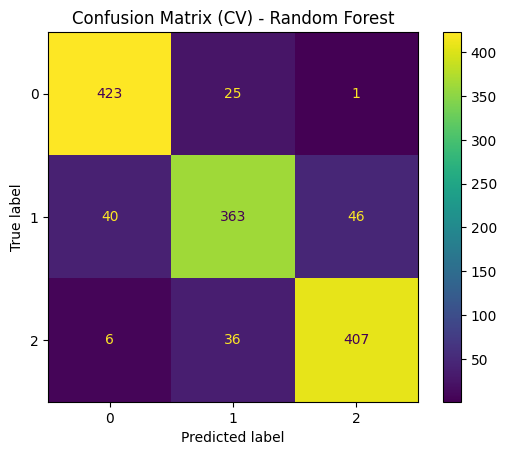

In [16]:
ConfusionMatrixDisplay.from_predictions(y_train_encoded, y_pred_rf_cv)
plt.title("Confusion Matrix (CV) - Random Forest")
plt.show()

Random Forest improves the performance of class 1.

XGBoost

In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'reg_alpha': [0, 0.1],
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=xgb_param_grid,
    cv=gkf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train_encoded, groups=train_groups)

print(f"Best XGB Params: {xgb_grid_search.best_params_}")
print(f"Best XGB CV Score: {xgb_grid_search.best_score_:.4f}")

best_xgb = xgb_grid_search.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0}
Best XGB CV Score: 0.8794


In [18]:
y_pred_xgb_cv = cross_val_predict(
    best_xgb,
    X_train,
    y_train_encoded,
    cv=gkf,
    groups=train_groups
)

acc_xgb_cv = accuracy_score(y_train_encoded, y_pred_xgb_cv)
print(f"XGB CV Accuracy: {acc_xgb_cv:.4f}")

print("XGB CV Classification Report:")
print(classification_report(y_train_encoded, y_pred_xgb_cv))

macro_f1_xgb = f1_score(y_train_encoded, y_pred_xgb_cv, average='macro')
print(f"XGB CV Macro F1: {macro_f1_xgb:.4f}")

XGB CV Accuracy: 0.8790
XGB CV Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       449
           1       0.82      0.84      0.83       449
           2       0.89      0.88      0.89       449

    accuracy                           0.88      1347
   macro avg       0.88      0.88      0.88      1347
weighted avg       0.88      0.88      0.88      1347

XGB CV Macro F1: 0.8793


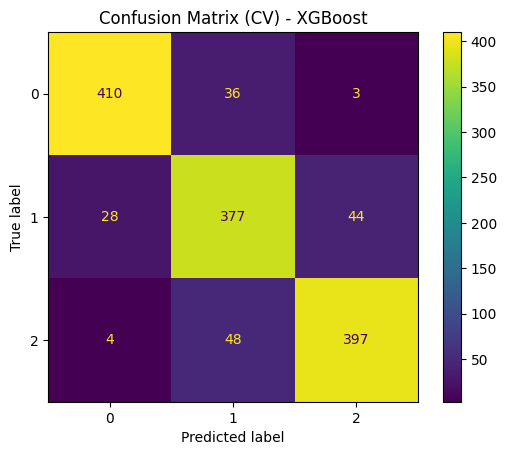

In [19]:
ConfusionMatrixDisplay.from_predictions(y_train_encoded, y_pred_xgb_cv)
plt.title("Confusion Matrix (CV) - XGBoost")
plt.show()

XGBoost has a more balanced overall performance.

Use the normalized Confusion Matrix for final visual.

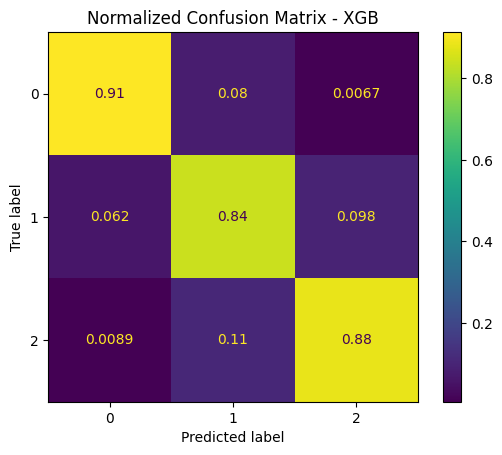

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_train_encoded,
    y_pred_xgb_cv,
    normalize='true'
)
plt.title("Normalized Confusion Matrix - XGB")
plt.show()

#### Error Analysis

In [25]:
y_pred = y_pred_xgb_cv
errors_mask = (y_train_encoded != y_pred)

print(f"Total samples: {len(y_train_encoded)}")
print(f"Number of errors: {np.sum(errors_mask)}")
print(f"Error rate: {np.mean(errors_mask):.4f}")

Total samples: 1347
Number of errors: 163
Error rate: 0.1210


In [26]:
X_errors = X_train[errors_mask]
y_true_errors = y_train_encoded[errors_mask]
y_pred_errors = y_pred[errors_mask]

error_df = pd.DataFrame({
    "true": y_true_errors,
    "pred": y_pred_errors
})

print("Error distribution (true vs pred):")
print(pd.crosstab(error_df["true"], error_df["pred"]))

Error distribution (true vs pred):
pred   0   1   2
true            
0      0  36   3
1     28   0  44
2      4  48   0


In [27]:
total_per_class = pd.Series(y_train_encoded).value_counts().sort_index()
error_per_class = pd.Series(y_true_errors).value_counts().sort_index()

error_rate_per_class = error_per_class / total_per_class

print("Error rate per class:")
print(error_rate_per_class)

Error rate per class:
0    0.086860
1    0.160356
2    0.115813
Name: count, dtype: float64


This also confirms that class 1 is the most likely to be wrong.

In [28]:
print("Where errors go (true -> predicted):")

for true_label in sorted(error_df["true"].unique()):
    subset = error_df[error_df["true"] == true_label]
    print(f"\nTrue class {true_label}:")
    print(subset["pred"].value_counts())

Where errors go (true -> predicted):

True class 0:
pred
1    36
2     3
Name: count, dtype: int64

True class 1:
pred
2    44
0    28
Name: count, dtype: int64

True class 2:
pred
1    48
0     4
Name: count, dtype: int64


In [41]:
top_errors = np.where(errors_mask)[0][:10]
print("Sample error indices:", top_errors)

Sample error indices: [  8  18 102 146 165 166 174 178 182 185]


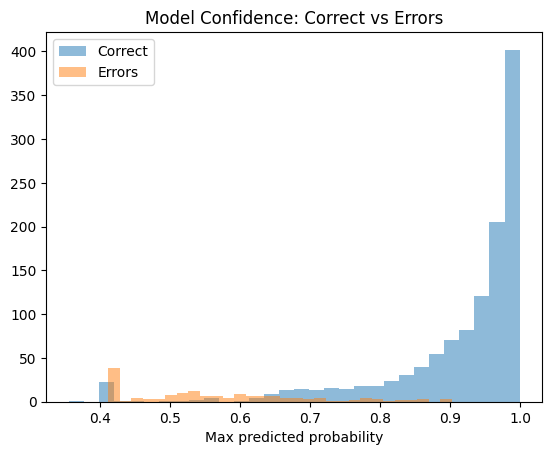

In [30]:
correct_mask = ~errors_mask
probs = best_xgb.predict_proba(X_train)

confidence = np.max(probs, axis=1)

plt.figure()
plt.hist(confidence[correct_mask], bins=30, alpha=0.5, label="Correct")
plt.hist(confidence[errors_mask], bins=30, alpha=0.5, label="Errors")
plt.legend()
plt.title("Model Confidence: Correct vs Errors")
plt.xlabel("Max predicted probability")
plt.show()

Finally, on the test set:

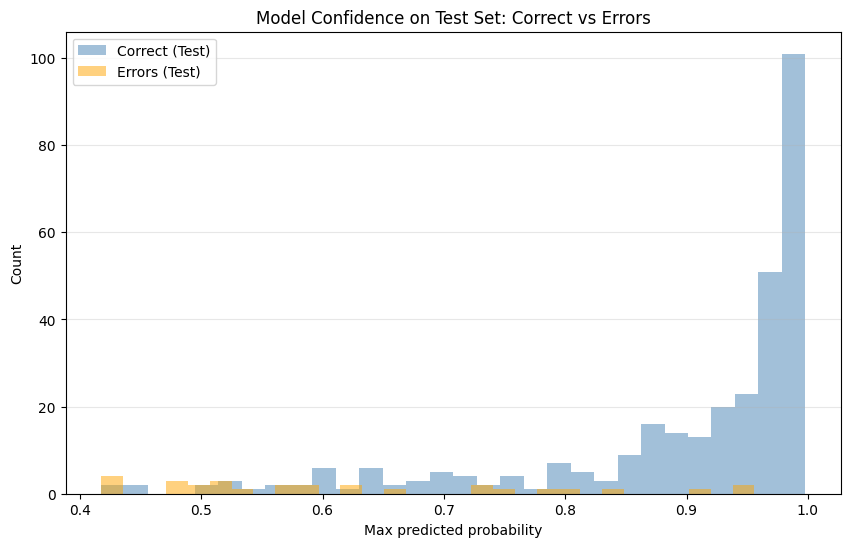

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       113
           1       0.91      0.88      0.89       113
           2       0.91      0.93      0.92       113

    accuracy                           0.91       339
   macro avg       0.91      0.91      0.91       339
weighted avg       0.91      0.91      0.91       339



In [33]:
test_probs = best_xgb.predict_proba(X_test)
test_preds = best_xgb.predict(X_test)

test_confidence = np.max(test_probs, axis=1)

test_errors_mask = (test_preds != y_test_encoded)
test_correct_mask = ~test_errors_mask

plt.figure(figsize=(10, 6))
plt.hist(test_confidence[test_correct_mask], bins=30, alpha=0.5, label="Correct (Test)", color='steelblue')
plt.hist(test_confidence[test_errors_mask], bins=30, alpha=0.5, label="Errors (Test)", color='orange')

plt.legend()
plt.title("Model Confidence on Test Set: Correct vs Errors")
plt.xlabel("Max predicted probability")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(classification_report(y_test_encoded, test_preds))

The model shows strong discriminative power on the test set, with correct predictions highly concentrated in the high-confidence region ($>0.95$). Misclassifications are primarily sparse and restricted to low-probability bins ($<0.6$), indicating that the model "knows when it doesn't know." Overall, the predicted probabilities serve as a reliable indicator of actual performance.

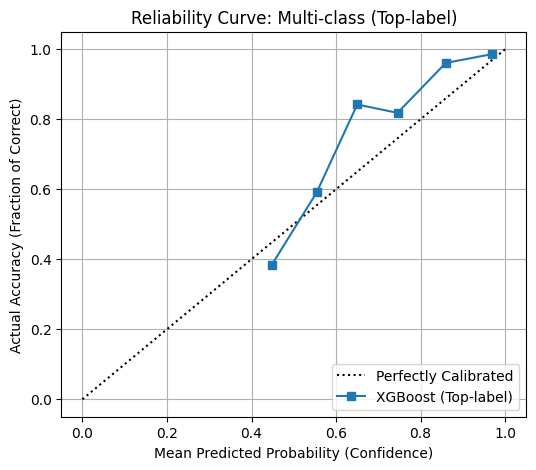

In [40]:
from sklearn.calibration import calibration_curve
test_confidence = np.max(test_probs, axis=1)
test_preds = best_xgb.predict(X_test)
is_correct = (test_preds == y_test_encoded).astype(int)

prob_true, prob_pred = calibration_curve(is_correct, test_confidence, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")
plt.plot(prob_pred, prob_true, "s-", label="XGBoost (Top-label)")

plt.xlabel("Mean Predicted Probability (Confidence)")
plt.ylabel("Actual Accuracy (Fraction of Correct)")
plt.title("Reliability Curve: Multi-class (Top-label)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The model demonstrates strong calibration and reliability, with most correct predictions clustered in the high-confidence range ($>0.95$). The reliability curve stays above the diagonal, indicating a slightly under-confident model where actual accuracy consistently exceeds predicted probabilities. This suggests the model is conservative and dependable for threshold-based decision-making.

### Save the model